# 06 — ML Models: Predicting Engagement & Clustering Subreddits

Three ML tasks:
- **Q8** — Random Forest Classifier: predict high engagement (top 25% score)
- **Q9** — Random Forest Regressor: predict comment count
- **Q10** — K-Means Clustering: group subreddits by behavior

### 1. Setup

In [1]:
import sys
sys.path.insert(0, "..")

from utils import (
    get_spark, load_cricket_submissions,
    add_player_mentions, add_time_features, label_event_period,
    save_figure, save_pandas_to_local,
)

from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, avg, when, sum as ssum
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator, ClusteringEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

### 2. Start Spark

In [2]:
spark = get_spark("06_MLModels")
spark

:: loading settings :: url = jar:file:/home/ubuntu/spark-3.5.1-bin-hadoop3/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ubuntu/.ivy2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-35734d8f-59bc-4078-9fb5-169dfce9a805;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 389ms :: artifacts dl 12ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evi

### 3. Load and prepare data

In [3]:
subs = load_cricket_submissions(spark)
subs = add_time_features(subs, ts_col="created_utc")
subs = label_event_period(subs, ts_col="created_dt")
subs = add_player_mentions(subs, text_col="title")
print("Data loaded and features added")

26/04/28 19:03:38 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Data loaded and features added


### 4. Select features and drop nulls

In [4]:
feature_cols = ["hour_of_day", "day_of_week", "month_num",
                "mentions_dhoni", "mentions_kohli", "mentions_rohit",
                "subreddit", "event_period"]

ml_df = subs.select(feature_cols + ["score", "num_comments"]).dropna()

for flag in ["mentions_dhoni", "mentions_kohli", "mentions_rohit"]:
    ml_df = ml_df.withColumn(flag, col(flag).cast("int"))

print(f"ML dataset rows: {ml_df.count():,}")

ML dataset rows: 242,886


### 5. Add labels — high engagement (Q8) and log comment count (Q9)

In [5]:
# Q8 label — top 25% score = high engagement
p75 = ml_df.approxQuantile("score", [0.75], 0.01)[0]
print(f"75th percentile score: {p75}")
ml_df = ml_df.withColumn("high_engagement", when(col("score") >= p75, 1).otherwise(0))

# Q9 label — num_comments directly
print(ml_df.groupBy("high_engagement").count().toPandas())

75th percentile score: 25.0


   high_engagement   count
0                1   63009
1                0  179877


### 6. Build pipeline — encode categoricals

In [6]:
sub_indexer = StringIndexer(inputCol="subreddit",    outputCol="subreddit_idx",    handleInvalid="keep")
evt_indexer = StringIndexer(inputCol="event_period", outputCol="event_period_idx", handleInvalid="keep")
sub_ohe     = OneHotEncoder(inputCol="subreddit_idx",    outputCol="subreddit_ohe")
evt_ohe     = OneHotEncoder(inputCol="event_period_idx", outputCol="event_period_ohe")

numeric_features = ["hour_of_day", "day_of_week", "month_num",
                    "mentions_dhoni", "mentions_kohli", "mentions_rohit"]

assembler = VectorAssembler(
    inputCols=numeric_features + ["subreddit_ohe", "event_period_ohe"],
    outputCol="features",
)

### 7. Train/test split

In [7]:
train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count():,}  |  Test: {test_df.count():,}")

Train: 194,496  |  Test: 48,390


### 8. Q8 — Random Forest Classifier (high engagement)

In [8]:
rf_clf = RandomForestClassifier(featuresCol="features", labelCol="high_engagement",
                                 numTrees=50, maxDepth=6, seed=42)
clf_pipeline = Pipeline(stages=[sub_indexer, evt_indexer, sub_ohe, evt_ohe, assembler, rf_clf])
clf_model = clf_pipeline.fit(train_df)
print("Q8 classifier trained")

Q8 classifier trained


### 9. Evaluate Q8 classifier

In [9]:
clf_preds = clf_model.transform(test_df)
auc = BinaryClassificationEvaluator(labelCol="high_engagement",
                                     rawPredictionCol="rawPrediction",
                                     metricName="areaUnderROC").evaluate(clf_preds)
accuracy = clf_preds.filter(col("prediction") == col("high_engagement")).count() / clf_preds.count()
print(f"Q8 — AUC-ROC: {auc:.4f}  |  Accuracy: {accuracy:.4f}")
save_pandas_to_local(pd.DataFrame({"metric": ["AUC-ROC", "Accuracy"], "value": [auc, accuracy]}),
                     "06_q8_classification_metrics.csv")

Q8 — AUC-ROC: 0.6733  |  Accuracy: 0.7386
Saved to results/tables/06_q8_classification_metrics.csv


### 10. Feature importances — Q8

Saved to results/figures/06_q8_feature_importances.png


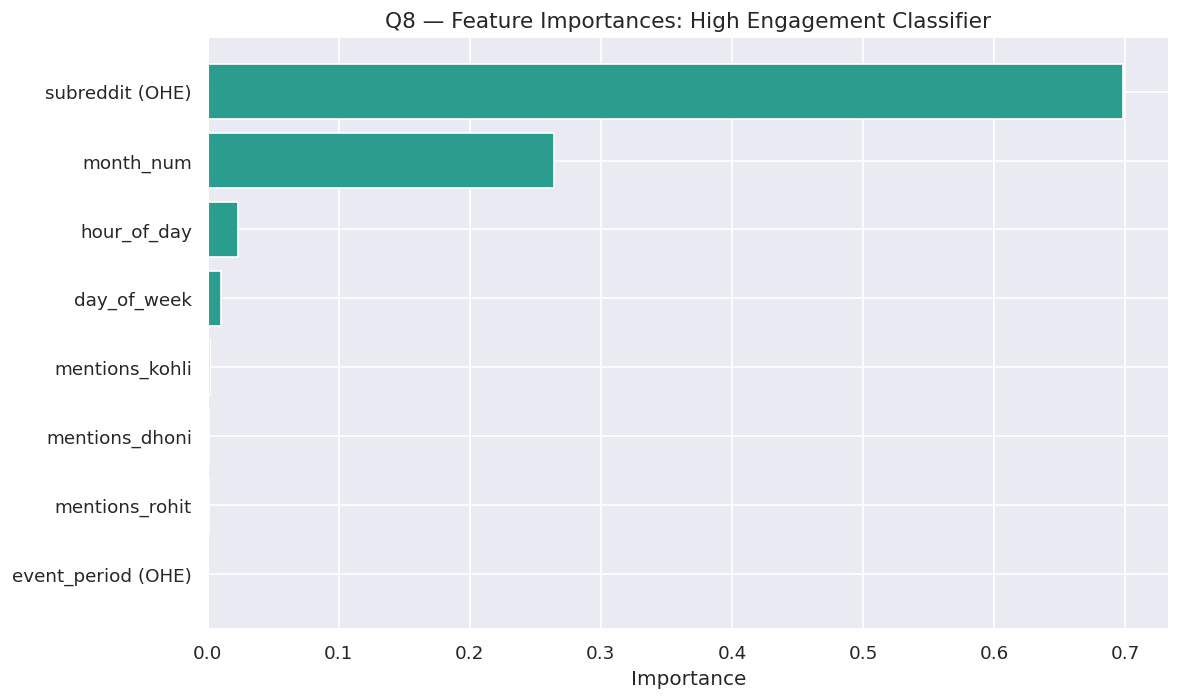

Saved to results/tables/06_q8_feature_importances.csv


In [10]:
importances = clf_model.stages[-1].featureImportances.toArray()
n = len(numeric_features)
imp_df = pd.DataFrame({
    "feature":    numeric_features + ["subreddit (OHE)", "event_period (OHE)"],
    "importance": importances[:n].tolist() + [float(importances[n:n+200].sum()), float(importances[n+200:].sum())],
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df["feature"], imp_df["importance"], color="#2a9d8f", edgecolor="white")
ax.set_title("Q8 — Feature Importances: High Engagement Classifier", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
save_figure(fig, "06_q8_feature_importances.png")
plt.show()
save_pandas_to_local(imp_df, "06_q8_feature_importances.csv")

### 11. Q9 — Random Forest Regressor (predict comment count)

In [11]:
rf_reg = RandomForestRegressor(featuresCol="features", labelCol="num_comments",
                                numTrees=50, maxDepth=6, seed=42)
reg_pipeline = Pipeline(stages=[sub_indexer, evt_indexer, sub_ohe, evt_ohe, assembler, rf_reg])
reg_model = reg_pipeline.fit(train_df)
print("Q9 regressor trained")

Q9 regressor trained


### 12. Evaluate Q9 regressor

In [12]:
reg_preds = reg_model.transform(test_df)
rmse = RegressionEvaluator(labelCol="num_comments", predictionCol="prediction", metricName="rmse").evaluate(reg_preds)
r2   = RegressionEvaluator(labelCol="num_comments", predictionCol="prediction", metricName="r2").evaluate(reg_preds)
print(f"Q9 — RMSE: {rmse:.2f}  |  R²: {r2:.4f}")
save_pandas_to_local(pd.DataFrame({"metric": ["RMSE", "R2"], "value": [rmse, r2]}),
                     "06_q9_regression_metrics.csv")

Q9 — RMSE: 382.97  |  R²: 0.0162
Saved to results/tables/06_q9_regression_metrics.csv


### 13. Q9 — Predicted vs Actual comment count chart

Saved to results/figures/06_q9_predicted_vs_actual.png


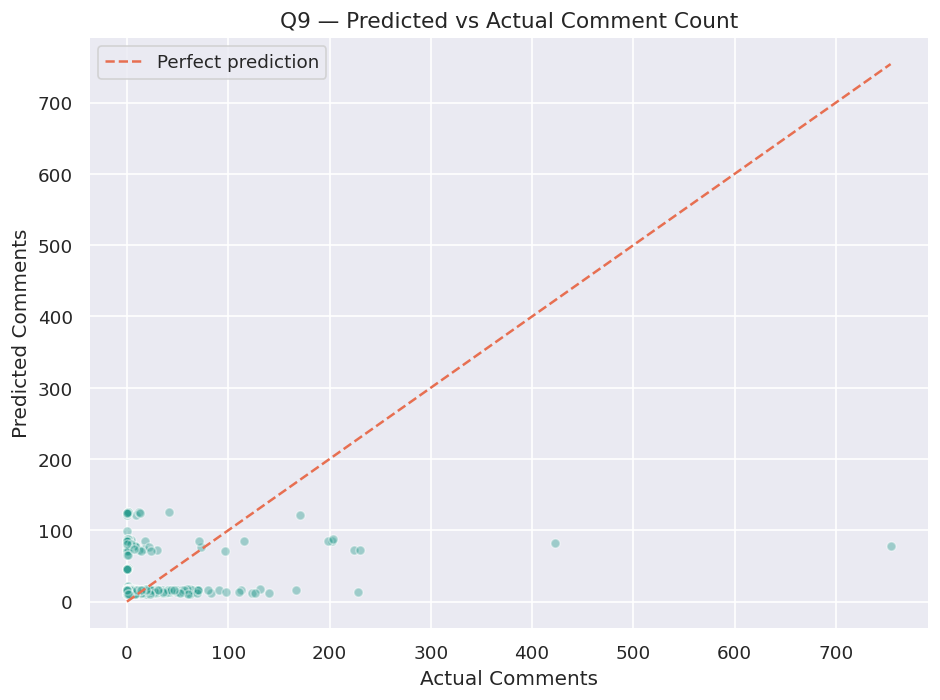

In [13]:
pred_sample = reg_preds.select("num_comments", "prediction").limit(500).toPandas()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pred_sample["num_comments"], pred_sample["prediction"],
           alpha=0.4, color="#2a9d8f", edgecolors="white", s=30)
max_val = max(pred_sample["num_comments"].max(), pred_sample["prediction"].max())
ax.plot([0, max_val], [0, max_val], color="#e76f51", linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set_title("Q9 — Predicted vs Actual Comment Count", fontsize=13)
ax.set_xlabel("Actual Comments")
ax.set_ylabel("Predicted Comments")
ax.legend()
plt.tight_layout()
save_figure(fig, "06_q9_predicted_vs_actual.png")
plt.show()

### 14. Q10 — K-Means Clustering on subreddit behavior

In [14]:
# Build subreddit-level feature vectors
sub_features = subs.groupBy("subreddit").agg(
    count("*").alias("post_count"),
    avg("score").alias("avg_score"),
    avg("num_comments").alias("avg_comments"),
    ssum(col("mentions_dhoni").cast("int")).alias("dhoni_mentions"),
    ssum(col("mentions_kohli").cast("int")).alias("kohli_mentions"),
    ssum(col("mentions_rohit").cast("int")).alias("rohit_mentions"),
    avg("hour_of_day").alias("avg_post_hour"),
).filter(col("post_count") >= 50).dropna()

print(f"Subreddits for clustering: {sub_features.count()}")
sub_features.show(10, truncate=False)

Subreddits for clustering: 18


+-------------------+----------+------------------+--------------------+--------------+--------------+--------------+------------------+
|subreddit          |post_count|avg_score         |avg_comments        |dhoni_mentions|kohli_mentions|rohit_mentions|avg_post_hour     |
+-------------------+----------+------------------+--------------------+--------------+--------------+--------------+------------------+
|delhicapitals      |2522      |23.427835051546392|15.979777954004758  |6             |17            |19            |11.397700237906424|
|IndianCricket      |85        |1.2352941176470589|0.058823529411764705|1             |5             |2             |11.388235294117647|
|KolkataKnightRiders|8030      |38.78717310087173 |6.645703611457036   |15            |37            |39            |10.897260273972602|
|IndiaCricket       |40469     |79.5976179297734  |10.98957226519064   |1117          |2813          |2492          |10.78487237144481 |
|RCB                |9416      |54.812871

### 15. Fit K-Means (k=4 clusters)

In [15]:
km_assembler = VectorAssembler(
    inputCols=["post_count", "avg_score", "avg_comments",
               "dhoni_mentions", "kohli_mentions", "rohit_mentions", "avg_post_hour"],
    outputCol="km_features_raw"
)

scaler = StandardScaler(inputCol="km_features_raw", outputCol="km_features",
                        withStd=True, withMean=True)

kmeans = KMeans(featuresCol="km_features", predictionCol="cluster", k=4, seed=42)

km_pipeline = Pipeline(stages=[km_assembler, scaler, kmeans])
km_model = km_pipeline.fit(sub_features)

clustered = km_model.transform(sub_features)
silhouette = ClusteringEvaluator(featuresCol="km_features", predictionCol="cluster").evaluate(clustered)
print(f"Silhouette score: {silhouette:.4f}")

26/04/28 19:26:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Silhouette score: 0.1953


### 16. Show cluster assignments

In [16]:
cluster_df = clustered.select("subreddit", "post_count", "avg_score", "avg_comments", "cluster").toPandas()
cluster_df = cluster_df.sort_values(["cluster", "post_count"], ascending=[True, False])

for c in sorted(cluster_df["cluster"].unique()):
    print(f"\nCluster {c}:")
    print(cluster_df[cluster_df["cluster"] == c][["subreddit", "post_count", "avg_score", "avg_comments"]].to_string(index=False))

save_pandas_to_local(cluster_df, "06_q10_subreddit_clusters.csv")


Cluster 0:
          subreddit  post_count  avg_score  avg_comments
                ipl       20812  93.550211     14.949212
             HiTMAN       20191  39.991828     10.480016
                RCB        9416  54.812872     11.362256
KolkataKnightRiders        8030  38.787173      6.645704
                csk        5016  50.761762     11.112839
      MumbaiIndians        4405  61.135528     15.250397
 SunrisersHyderabad        4320  67.314120     14.143056
      delhicapitals        2522  23.427835     15.979778
     EnglandCricket        1060  26.701887      7.368868
         ViratKohli         993  26.146022      1.262840
        RohitSharma         135  73.170370      2.688889
      IndianCricket          85   1.235294      0.058824

Cluster 1:
subreddit  post_count  avg_score  avg_comments
  Cricket       65562  47.706385     65.492099

Cluster 2:
      subreddit  post_count  avg_score  avg_comments
CricketShitpost       47453 118.375951      8.694982
   IndiaCricket       4

### 17. Chart — subreddit clusters by avg score vs avg comments

Saved to results/figures/06_q10_subreddit_clusters.png


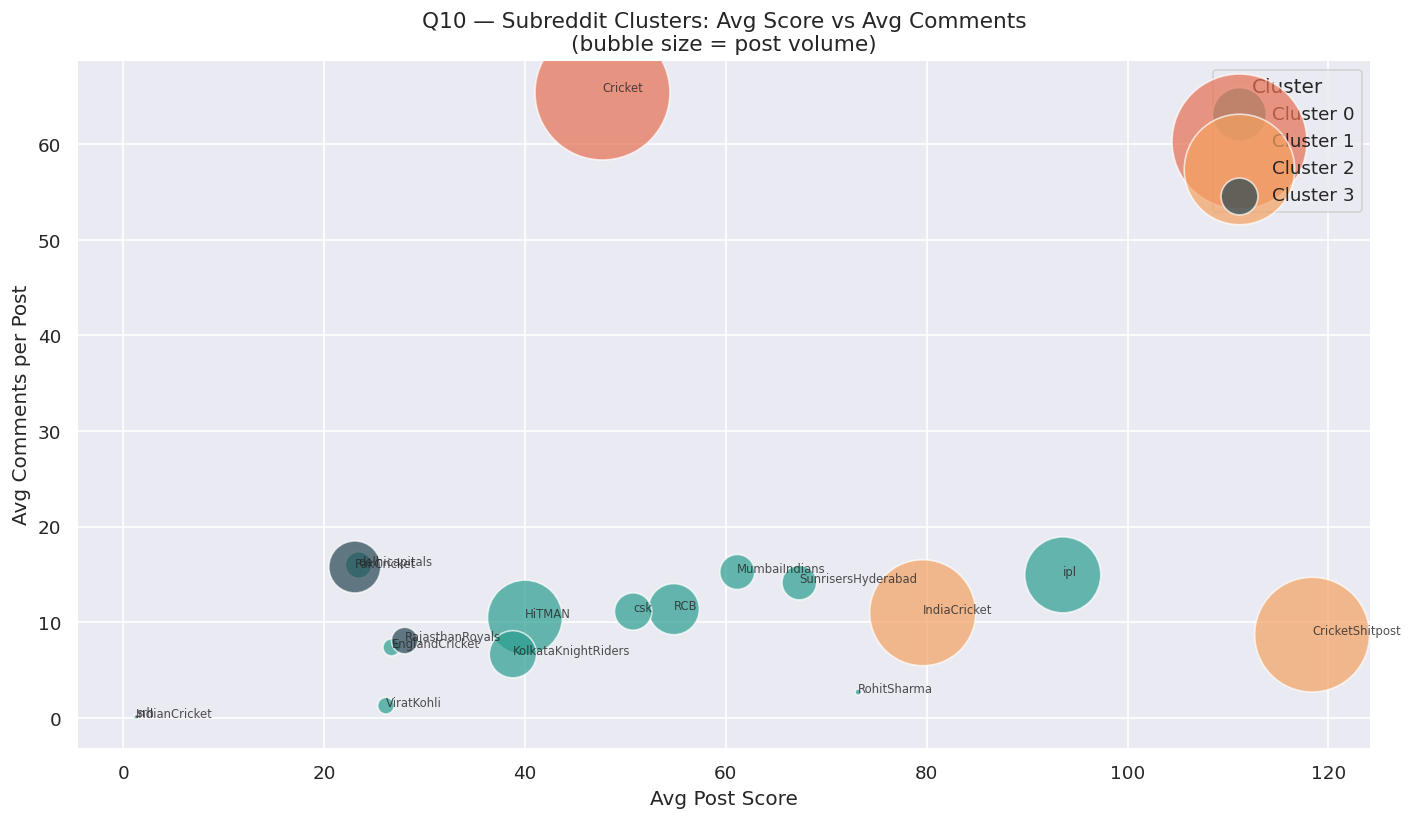

In [17]:
cluster_colors = ["#2a9d8f", "#e76f51", "#f4a261", "#264653"]

fig, ax = plt.subplots(figsize=(12, 7))
for c in sorted(cluster_df["cluster"].unique()):
    subset = cluster_df[cluster_df["cluster"] == c]
    ax.scatter(subset["avg_score"], subset["avg_comments"],
               color=cluster_colors[c], s=subset["post_count"]/10,
               alpha=0.7, label=f"Cluster {c}", edgecolors="white")
    for _, row in subset.iterrows():
        ax.annotate(row["subreddit"], (row["avg_score"], row["avg_comments"]),
                    fontsize=7, alpha=0.8)

ax.set_title("Q10 — Subreddit Clusters: Avg Score vs Avg Comments\n(bubble size = post volume)", fontsize=13)
ax.set_xlabel("Avg Post Score")
ax.set_ylabel("Avg Comments per Post")
ax.legend(title="Cluster")
plt.tight_layout()
save_figure(fig, "06_q10_subreddit_clusters.png")
plt.show()

### 18. Summary table — all three models

In [18]:
summary = pd.DataFrame({
    "Question": ["Q8", "Q9", "Q10"],
    "Model":    ["RF Classifier", "RF Regressor", "K-Means (k=4)"],
    "Task":     ["Predict high engagement (top 25%)", "Predict comment count", "Cluster subreddits by behavior"],
    "Result":   [f"AUC={auc:.4f}, Acc={accuracy:.4f}", f"RMSE={rmse:.2f}, R²={r2:.4f}", f"Silhouette={silhouette:.4f}"],
})
print(summary.to_string(index=False))
save_pandas_to_local(summary, "06_model_summary.csv")

Question         Model                              Task                 Result
      Q8 RF Classifier Predict high engagement (top 25%) AUC=0.6733, Acc=0.7386
      Q9  RF Regressor             Predict comment count RMSE=382.97, R²=0.0162
     Q10 K-Means (k=4)    Cluster subreddits by behavior      Silhouette=0.1953
Saved to results/tables/06_model_summary.csv


### 19. Stop Spark

In [19]:
spark.stop()